# Network Analysis — MQTT Broker Comparison

Analyses PCAP files captured during benchmark runs to compare broker behaviour:
- **Throughput**: MQTT payload bytes per second at the broker
- **Connection overhead**: Time from TCP SYN to first MQTT PUBLISH (critical for per-message-reconnect pattern)
- **RTT**: TCP round-trip time distribution (broker responsiveness)
- **TCP health**: retransmissions, zero-window, resets (root causes of packet loss)
- **Multi-broker summary**: side-by-side comparison table and bar charts

In [ ]:
import subprocess, shutil, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

TSHARK = shutil.which('tshark') or '/usr/bin/tshark'

plt.rcParams.update({'figure.autolayout': True})

# ── Discover PCAPs ────────────────────────────────────────────────
RESULTS_DIR  = Path('../results')

# Discover PCAPs from production result directories (exclude val/test runs).
_candidates = [
    p for p in RESULTS_DIR.glob('*/captures/*.pcap')
    if not p.name.startswith('_')
    and not any(tag in p.parent.parent.name for tag in ('_val', '_test'))
]

_best = {}
for p in _candidates:
    if p.name.startswith('_'):
        continue
    stem = p.stem.replace('_s200', '')
    existing = _best.get(stem)
    if existing is None:
        _best[stem] = p
    elif '_s200' in p.name and '_s200' not in existing.name:
        _best[stem] = p

def _payload_bytes(path):
    m = re.search(r'_(\d+)(kb|mb)_', path.name, re.IGNORECASE)
    if not m:
        return 0
    n, unit = int(m.group(1)), m.group(2).lower()
    return n * (1024 if unit == 'kb' else 1024 ** 2)

# Sort by payload size ascending then broker name so small captures run and cache first.
pcap_files = sorted(_best.values(), key=lambda x: (_payload_bytes(x), x.name))

if not pcap_files:
    raise FileNotFoundError(
        f'No .pcap files found under {CAPTURES_DIR} or {RESULTS_DIR}/**/captures/'
    )

print(f'Found {len(pcap_files)} PCAP file(s):')
for p in pcap_files:
    tag = ' [stripped]' if '_s200' in p.name else ''
    cjson = p.with_name(p.stem + '.cache.json')
    tag += ' [cached]' if cjson.exists() else ''
    print(f'  {p.name}  ({p.stat().st_size/1024**2:.0f} MB){tag}')


Found 13 PCAP file(s):
  emqx_35kb_qos0_20260420T080950_s200.pcap  (121 MB) [stripped] [cached]
  hivemq_35kb_qos0_20260420T051825_s200.pcap  (118 MB) [stripped] [cached]
  mosquitto_35kb_qos0_20260420T110151_s200.pcap  (134 MB) [stripped] [cached]
  nanomq_35kb_qos0_20260420T135213_s200.pcap  (121 MB) [stripped] [cached]
  emqx_125kb_qos0_20260420T235149_s200.pcap  (204 MB) [stripped] [cached]
  hivemq_125kb_qos0_20260420T174511_s200.pcap  (141 MB) [stripped] [cached]
  mosquitto_125kb_qos0_20260420T204916_s200.pcap  (211 MB) [stripped] [cached]
  nanomq_125kb_qos0_20260421T025452_s200.pcap  (213 MB) [stripped] [cached]
  emqx_1mb_qos0_20260503T211148_s200.pcap  (648 MB) [stripped] [cached]
  hivemq_1mb_qos0_20260421T204444_s200.pcap  (720 MB) [stripped] [cached]
  mosquitto_1mb_qos0_20260421T235150_s200.pcap  (592 MB) [stripped] [cached]
  nanomq_1mb_qos0_20260422T025433_s200.pcap  (607 MB) [stripped] [cached]
  rabbitmq_1mb_qos0_20260505T170044_s200.pcap  (574 MB) [stripped] [cached

## Extraction helpers

In [ ]:
import subprocess, json, gc
import numpy as np
from pathlib import Path

# ── Single-pass extraction ───────────────────────────────────────────────────
def extract_all(pcap):
    """One tshark pass over the PCAP. Computes every stat needed by this notebook.
    Returns a dict with scalar stats, numpy arrays (rtt_arr, ovh_arr), and
    timeline dicts keyed by integer second-offset from capture start.
    """
    cmd = [
        TSHARK, '-r', str(pcap),
        '-Y', 'tcp.port == 1883',
        '-T', 'fields', '-E', 'separator=\t',
        '-e', 'frame.time_epoch',   # 0
        '-e', 'tcp.stream',         # 1
        '-e', 'tcp.len',            # 2
        '-e', 'tcp.flags.syn',      # 3
        '-e', 'tcp.flags.ack',      # 4
        '-e', 'tcp.flags.reset',    # 5
        '-e', 'tcp.analysis.retransmission',  # 6
        '-e', 'tcp.analysis.zero_window',     # 7
        '-e', 'tcp.analysis.ack_rtt',         # 8
        '-e', 'mqtt.msgtype',                 # 9
    ]

    t_min = t_max = None
    total_bytes = retrans = zero_win = resets = pub_count = n_packets = 0
    rtt_list  = []
    syn_t     = {}   # stream -> first SYN epoch
    first_pub = {}   # stream -> first PUBLISH epoch
    timeline  = {}   # second_offset -> {bytes, retrans, zw, pub}

    with subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.DEVNULL,
                          text=True, bufsize=1 << 20) as proc:
        for raw in proc.stdout:
            parts = raw.rstrip('\n').split('\t')
            if len(parts) < 10:
                continue

            # ── timestamp ───────────────────────────────────────────────────
            try:
                ts = float(parts[0])
            except ValueError:
                continue

            if t_min is None: t_min = ts
            t_max = ts

            # ── timeline bucket ─────────────────────────────────────────────
            sec = int(ts - t_min) if t_min else 0
            bkt = timeline.setdefault(sec, {'bytes': 0, 'retrans': 0, 'zw': 0, 'pub': 0})

            # ── tcp.len ──────────────────────────────────────────────────────
            try:
                nb_bytes = int(parts[2]) if parts[2] else 0
            except ValueError:
                nb_bytes = 0
            total_bytes += nb_bytes
            bkt['bytes'] += nb_bytes

            # ── flags / analysis ────────────────────────────────────────────
            if parts[6]:                  # retransmission
                retrans += 1; bkt['retrans'] += 1
            if parts[7]:                  # zero window
                zero_win += 1; bkt['zw'] += 1
            if parts[5] == '1':           # RST
                resets += 1

            # ── RTT ──────────────────────────────────────────────────────────
            if parts[8]:
                try:
                    rtt_list.append(float(parts[8]) * 1000)
                except ValueError:
                    pass

            # ── MQTT PUBLISH ──────────────────────────────────────────────────
            stream = parts[1]
            if parts[9] == '3':
                pub_count += 1; bkt['pub'] += 1
                if stream and stream not in first_pub:
                    first_pub[stream] = ts

            # ── SYN (not SYN-ACK) ────────────────────────────────────────────
            if parts[3] == '1' and parts[4] != '1':
                if stream and stream not in syn_t:
                    syn_t[stream] = ts

            n_packets += 1

    duration = (t_max - t_min) if (t_min and t_max) else 1

    # Connection overhead per stream
    ovh_list = []
    for s, st in syn_t.items():
        pt = first_pub.get(s)
        if pt and pt > st:
            ovh_list.append((pt - st) * 1000)

    rtt_arr = np.array(rtt_list,  dtype=np.float32)
    ovh_arr = np.array(ovh_list,  dtype=np.float32)

    def pct(arr, q):
        return round(float(np.percentile(arr, q)), 2) if len(arr) else None

    return {
        # scalars
        'duration_s':           round(duration, 1),
        'total_bytes':          total_bytes,
        'n_packets':            n_packets,
        'mqtt_publishes':       pub_count,
        'throughput_KB/s':      round(total_bytes / max(duration, 1) / 1024, 1),
        'rtt_p50_ms':           pct(rtt_arr, 50),
        'rtt_p95_ms':           pct(rtt_arr, 95),
        'rtt_p99_ms':           pct(rtt_arr, 99),
        'conn_overhead_p50_ms': pct(ovh_arr, 50),
        'conn_overhead_p95_ms': pct(ovh_arr, 95),
        'retransmissions':      retrans,
        'retrans_rate_%':       round(100 * retrans / max(n_packets, 1), 3),
        'zero_window_events':   zero_win,
        'tcp_resets':           resets,
        # arrays (for plot cells)
        'rtt_arr':  rtt_arr,
        'ovh_arr':  ovh_arr,
        'timeline': timeline,   # {sec_offset: {bytes,retrans,zw,pub}}
    }


# ── Disk cache ───────────────────────────────────────────────────────────────
def _cache_paths(pcap):
    base = Path(pcap).with_suffix('')
    return base.with_suffix('.cache.json'), base.with_suffix('.cache.npz')

def load_cache(pcap):
    """Return cached stats dict or None if no cache exists."""
    jpath, npath = _cache_paths(pcap)
    if not (jpath.exists() and npath.exists()):
        return None
    with open(jpath) as f:
        d = json.load(f)
    npz = np.load(npath)
    d['rtt_arr']  = npz['rtt_arr']
    d['ovh_arr']  = npz['ovh_arr']
    # timeline stored as parallel int16 arrays to save space
    offsets = npz['tl_sec'].astype(int)
    d['timeline'] = {
        int(s): {'bytes':   int(b), 'retrans': int(r),
                 'zw':      int(z), 'pub':     int(p)}
        for s, b, r, z, p in zip(
            offsets, npz['tl_bytes'], npz['tl_retrans'],
            npz['tl_zw'], npz['tl_pub'])
    }
    return d

def save_cache(pcap, stats):
    """Write stats to .cache.json + .cache.npz next to the PCAP."""
    jpath, npath = _cache_paths(pcap)
    scalars = {k: v for k, v in stats.items()
               if k not in ('rtt_arr', 'ovh_arr', 'timeline')}
    with open(jpath, 'w') as f:
        json.dump(scalars, f)

    tl = stats['timeline']
    secs = sorted(tl)
    np.savez_compressed(
        npath,
        rtt_arr   = stats['rtt_arr'].astype(np.float32),
        ovh_arr   = stats['ovh_arr'].astype(np.float32),
        tl_sec    = np.array(secs, dtype=np.int32),
        tl_bytes  = np.array([tl[s]['bytes']   for s in secs], dtype=np.int64),
        tl_retrans= np.array([tl[s]['retrans']  for s in secs], dtype=np.int32),
        tl_zw     = np.array([tl[s]['zw']       for s in secs], dtype=np.int32),
        tl_pub    = np.array([tl[s]['pub']       for s in secs], dtype=np.int32),
    )


def broker_label(pcap_path):
    name = Path(pcap_path).stem
    m = re.match(r'([a-zA-Z]+_[^_]+)_qos', name)
    return m.group(1) if m else name[:20]


print('Extraction helpers ready.')


Extraction helpers ready.


## Load all PCAPs


In [ ]:
import gc
summary_rows = []

for pcap in pcap_files:
    label = broker_label(pcap)
    pcap_mb = pcap.stat().st_size / 1024**2

    cached = load_cache(pcap)
    if cached:
        print(f'[cache] {label}  ({pcap_mb:.0f} MB)')
        stats = cached
    else:
        print(f'[tshark] {label}  ({pcap_mb:.0f} MB)  — first run, please wait...', flush=True)
        stats = extract_all(pcap)
        try:
            save_cache(pcap, stats)
            print(f'         cached → {Path(pcap).with_suffix(".cache.json").name}')
        except OSError as e:
            print(f'         [warn] cache write failed: {e}')

    summary_rows.append({'label': label, 'path': str(pcap), **{
        k: v for k, v in stats.items() if k not in ('rtt_arr','ovh_arr','timeline')
    }})

    pub   = stats['mqtt_publishes']
    re_   = stats['retransmissions']
    rst   = stats['tcp_resets']
    r50   = stats['rtt_p50_ms']
    c50   = stats['conn_overhead_p50_ms']
    print(f'         pub={pub}  retrans={re_}  resets={rst}  rtt_p50={r50}ms  conn_p50={c50}ms')

    del stats
    gc.collect()

print(f'\nDone. {len(summary_rows)} PCAPs.')


[cache] emqx_35kb  (121 MB)
         pub=75129  retrans=13  resets=0  rtt_p50=0.03ms  conn_p50=Nonems
[cache] hivemq_35kb  (118 MB)
         pub=64187  retrans=3  resets=0  rtt_p50=0.02ms  conn_p50=Nonems
[cache] mosquitto_35kb  (134 MB)
         pub=104918  retrans=2  resets=0  rtt_p50=0.02ms  conn_p50=Nonems
[cache] nanomq_35kb  (121 MB)
         pub=79970  retrans=23  resets=0  rtt_p50=0.03ms  conn_p50=Nonems
[cache] emqx_125kb  (204 MB)
         pub=77895  retrans=220  resets=0  rtt_p50=0.04ms  conn_p50=Nonems
[cache] hivemq_125kb  (141 MB)
         pub=45197  retrans=180  resets=0  rtt_p50=0.01ms  conn_p50=Nonems
[cache] mosquitto_125kb  (211 MB)
         pub=106204  retrans=38  resets=0  rtt_p50=0.03ms  conn_p50=Nonems
[cache] nanomq_125kb  (213 MB)
         pub=79665  retrans=179  resets=0  rtt_p50=0.03ms  conn_p50=Nonems
[cache] emqx_1mb  (648 MB)
         pub=79981  retrans=13924  resets=0  rtt_p50=0.04ms  conn_p50=Nonems
[cache] hivemq_1mb  (720 MB)
         pub=79874  retran

## Summary metrics table


In [ ]:
import pandas as pd

summary_df = (pd.DataFrame(summary_rows)
                .set_index('label')
                .drop(columns=['path', 'total_bytes', 'n_packets'], errors='ignore'))

pd.set_option('display.max_columns', None)
summary_df


,duration_s,mqtt_publishes,throughput_KB/s,rtt_p50_ms,rtt_p95_ms,rtt_p99_ms,conn_overhead_p50_ms,conn_overhead_p95_ms,retransmissions,retrans_rate_%,zero_window_events,tcp_resets
label,,,,,,,,,,,,
emqx_35kb,10254.9,75129,273.2,0.03,0.20,0.42,None,None,13,0.001,0,0
hivemq_35kb,10206.8,64187,275.9,0.02,3.38,13.17,None,None,3,0.000,1,0
mosquitto_35kb,10155.8,104918,277.6,0.02,0.23,0.43,None,None,2,0.000,0,0
nanomq_35kb,10104.4,79970,278.8,0.03,0.26,0.45,None,None,23,0.003,0,0
emqx_125kb,10912.1,77895,907.6,0.04,0.96,2.11,None,None,220,0.016,6939,0
hivemq_125kb,10949.2,45197,445.9,0.01,3.27,6.55,None,None,180,0.019,892,0
mosquitto_125kb,10880.0,106204,919.4,0.03,0.24,0.84,None,None,38,0.003,286,0
nanomq_125kb,10795.5,79665,926.7,0.03,0.32,0.56,None,None,179,0.013,4392,0
emqx_1mb,9824.7,79981,8338.0,0.04,0.53,5.16,None,None,13924,0.356,87874,0


## Comparison bar charts

**How to read these:**
- **Throughput**: higher is better — how many KB of MQTT payload the broker delivered per second
- **Connection overhead**: lower is better — time from TCP SYN to first PUBLISH; high values mean the broker is slow to accept/authenticate connections (critical since each gateway reconnects per message)
- **RTT p95**: lower is better — broker responsiveness at the tail
- **Retransmission rate**: lower is better — high values indicate buffer pressure or packet loss at TCP level

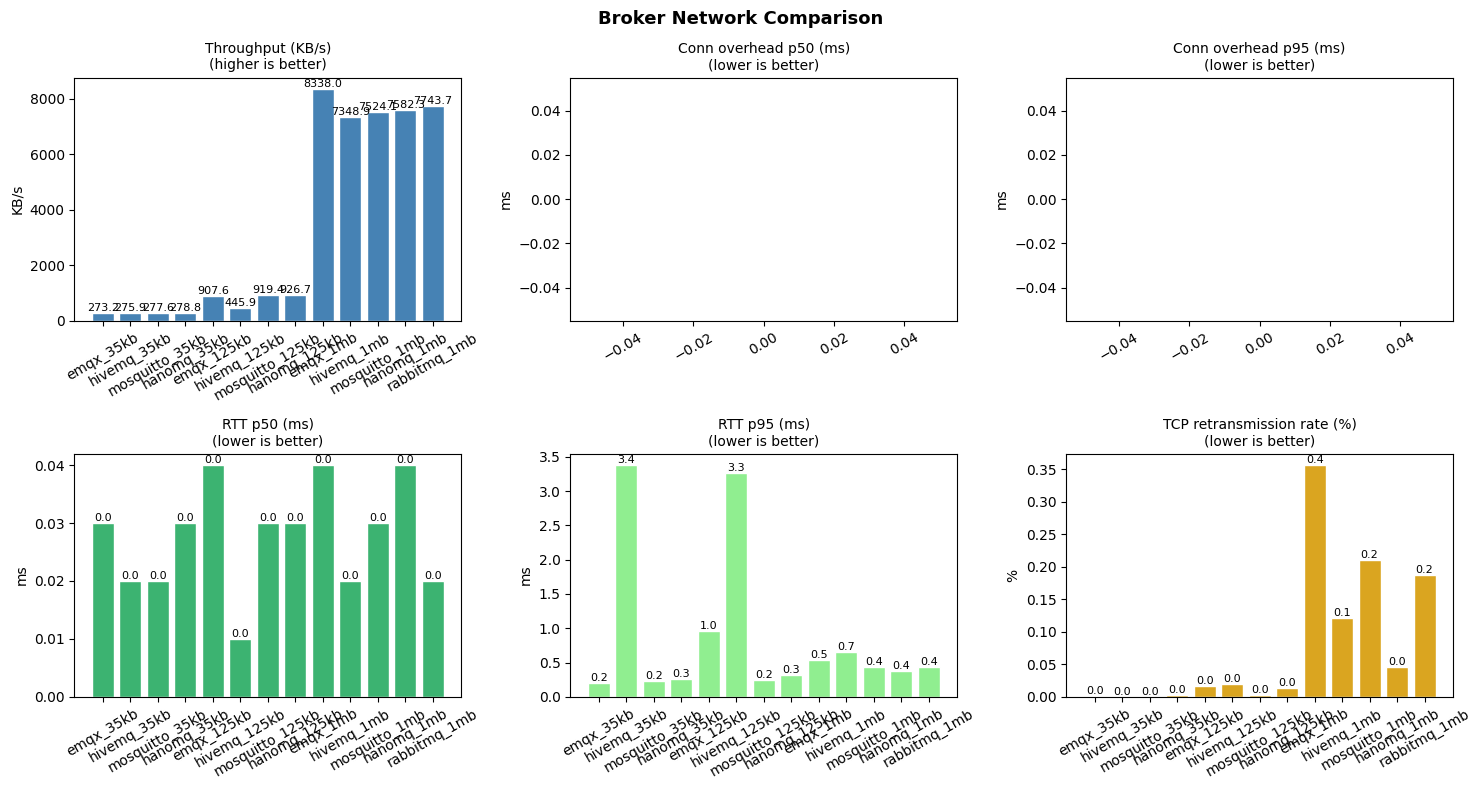

In [ ]:
if len(summary_df) < 2:
    print('Only one broker loaded — run benchmarks for other brokers and reload this notebook.')
    print('Showing single-broker metrics below instead.')

metrics = [
    ('throughput_KB/s',       'Throughput (KB/s)',               'higher is better', 'steelblue'),
    ('conn_overhead_p50_ms',  'Conn overhead p50 (ms)',          'lower is better',  'tomato'),
    ('conn_overhead_p95_ms',  'Conn overhead p95 (ms)',          'lower is better',  'salmon'),
    ('rtt_p50_ms',            'RTT p50 (ms)',                    'lower is better',  'mediumseagreen'),
    ('rtt_p95_ms',            'RTT p95 (ms)',                    'lower is better',  'lightgreen'),
    ('retrans_rate_%',        'TCP retransmission rate (%)',     'lower is better',  'goldenrod'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, (col, title, hint, color) in zip(axes, metrics):
    vals = summary_df[col].dropna()
    bars = ax.bar(vals.index, vals.values, color=color, edgecolor='white')
    ax.set_title(f'{title}\n({hint})', fontsize=10)
    ax.set_ylabel(col.split('_')[-1])
    ax.tick_params(axis='x', rotation=30)
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{v:.1f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Broker Network Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## RTT distribution


/tmp/ipykernel_35656/2391451363.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(rtt_data.values(), labels=rtt_data.keys(), showfliers=False, showmeans=True)


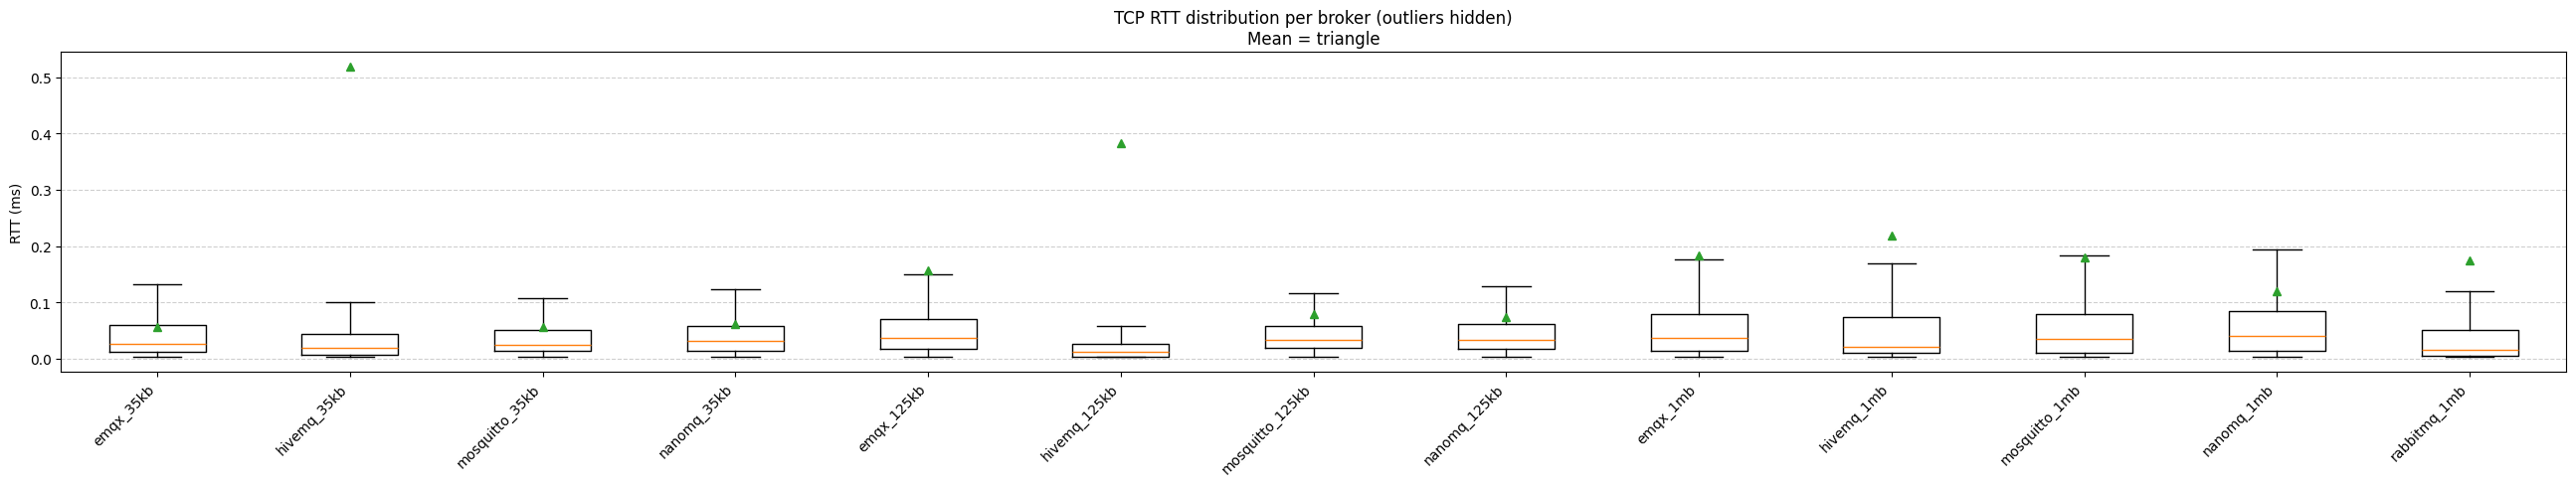

In [ ]:
rtt_data = {}
for row in summary_rows:
    cached = load_cache(row['path'])
    if cached and len(cached['rtt_arr']):
        rtt_data[row['label']] = cached['rtt_arr']
    del cached; gc.collect()

if rtt_data:
    fig, ax = plt.subplots(figsize=(max(6, len(rtt_data)*2), 5))
    ax.boxplot(rtt_data.values(), labels=rtt_data.keys(), showfliers=False, showmeans=True)
    ax.set_ylabel('RTT (ms)')
    ax.set_title('TCP RTT distribution per broker (outliers hidden)\nMean = triangle')
    ax.yaxis.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()
else:
    print('No RTT data.')


## Connection overhead


In [ ]:
conn_data = {}
for row in summary_rows:
    cached = load_cache(row['path'])
    if cached and len(cached['ovh_arr']):
        conn_data[row['label']] = cached['ovh_arr']
    del cached; gc.collect()

if conn_data:
    fig, ax = plt.subplots(figsize=(max(6, len(conn_data)*2), 5))
    ax.boxplot(conn_data.values(), labels=conn_data.keys(), showfliers=False, showmeans=True)
    ax.set_ylabel('Time SYN → first PUBLISH (ms)')
    ax.set_title('Connection + MQTT handshake overhead per broker\n'
                 '(lower = faster setup; directly adds to per-message latency)')
    ax.yaxis.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()
else:
    print('No SYN/PUBLISH data.')


No SYN/PUBLISH data.


## Network timeline


DTypePromotionError: The DType <class 'numpy.dtypes.TimeDelta64DType'> could not be promoted by <class 'numpy.dtypes.Float64DType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.TimeDelta64DType'>, <class 'numpy.dtypes.Float64DType'>)

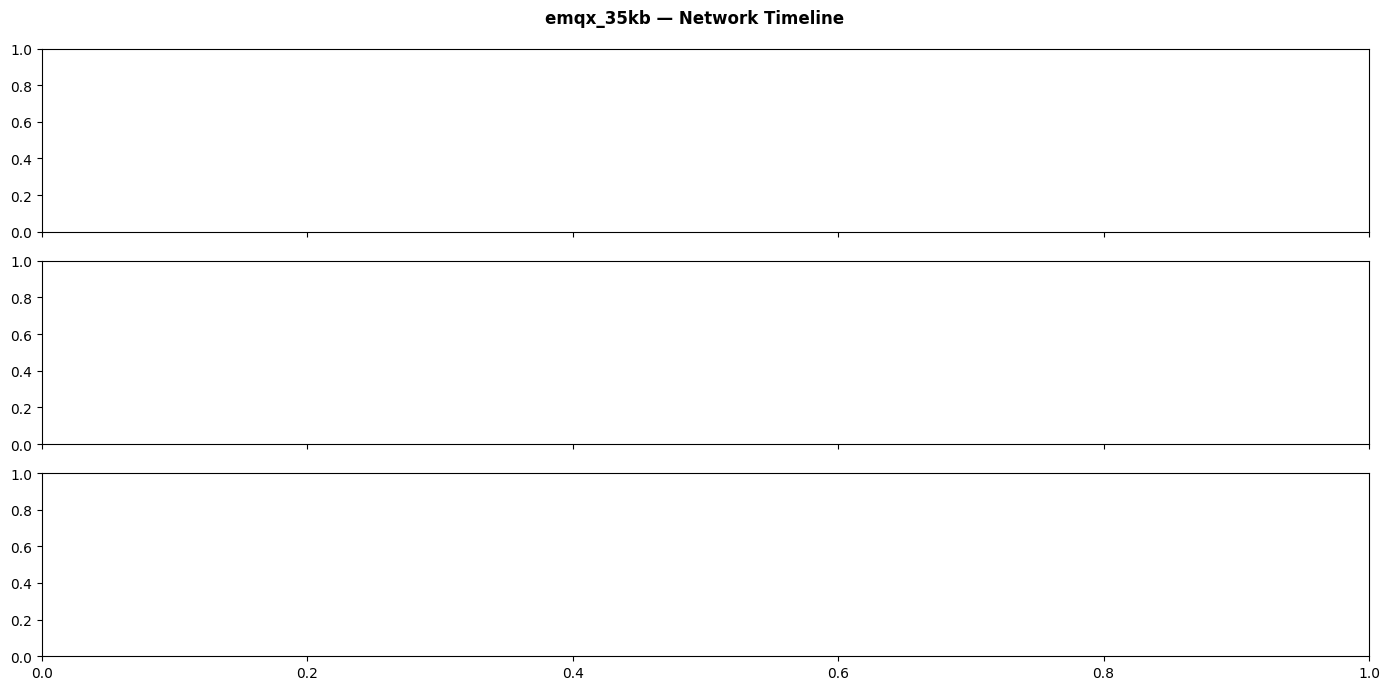

In [ ]:
for row in summary_rows:
    cached = load_cache(row['path'])
    if not cached or not cached['timeline']:
        continue

    tl     = cached['timeline']
    secs   = np.array(sorted(tl.keys()))
    ts_idx = pd.to_timedelta(secs, unit='s')

    throughput = pd.Series([tl[s]['bytes']   / 1024 for s in secs], index=ts_idx)
    retrans_s  = pd.Series([tl[s]['retrans']        for s in secs], index=ts_idx)
    zw_s       = pd.Series([tl[s]['zw']             for s in secs], index=ts_idx)
    pub_s      = pd.Series([tl[s]['pub']            for s in secs], index=ts_idx)

    fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)
    fig.suptitle(f"{row['label']} — Network Timeline", fontweight='bold')

    axes[0].fill_between(throughput.index, throughput.values, alpha=0.7, color='steelblue')
    axes[0].set_ylabel('KB/s'); axes[0].set_title('TCP throughput')

    axes[1].bar(pub_s.index, pub_s.values, width=pd.Timedelta('1s'), color='seagreen', alpha=0.8)
    axes[1].set_ylabel('count'); axes[1].set_title('MQTT PUBLISHes/s')

    axes[2].bar(retrans_s.index, retrans_s.values, width=pd.Timedelta('1s'),
                label='Retransmissions', color='tomato', alpha=0.8)
    axes[2].bar(zw_s.index, zw_s.values, width=pd.Timedelta('1s'),
                label='Zero-window', color='orange', alpha=0.8,
                bottom=retrans_s.reindex(zw_s.index, fill_value=0))
    axes[2].set_ylabel('count'); axes[2].set_title('TCP anomalies/s')
    axes[2].legend(fontsize=8)

    plt.tight_layout(); plt.show()
    del cached, tl, secs, throughput, retrans_s, zw_s, pub_s; gc.collect()


## Interpreting results for broker evaluation

| Signal | What it means | Root cause |
|---|---|---|
| High **retransmission rate** | TCP-level packet loss | Broker send buffer full, CPU overloaded, or network congestion |
| High **zero-window events** | Receiver told sender to stop — receive buffer full | Broker not reading messages fast enough (processing bottleneck) |
| High **TCP resets** | Connections abruptly terminated | Broker rejecting connections (max-client limit) or crashing |
| High **connection overhead** | Broker slow to accept connections | TLS overhead, auth latency, or thread-pool saturation |
| Low **throughput** despite low retrans | Broker is the bottleneck | Serialisation, persistence, or lock contention inside broker |
| **RTT spikes** at high load | Broker I/O queue backing up | GC pauses (JVM brokers), single-threaded dispatch |

For QoS 0, MQTT-level message loss is **not** visible in the PCAP (no ACKs to check).
Compare `mqtt_publishes` in the summary against `messages received` in the subscriber logs to get the true delivery rate.